# Merge de Dados: IBGE (População e Densidade) + INMET (Clima) — Bahia (2024)

Este notebook tem como objetivo principal:
1. Carregar e limpar os dados de População e Densidade Demográfica do IBGE (Censo 2022).
2. Iterar sobre os diretórios de dados meteorológicos do INMET (horários) referentes à Bahia.
3. Padronizar os nomes dos municípios e realizar o `merge` entre as bases.

In [3]:
from __future__ import annotations

import unicodedata
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Caminhos base (ajuste conforme a estrutura do seu projeto)
BASE_DIR = Path.cwd().parent # ou defina o caminho absoluto da raiz do seu projeto
DATA_RAW = BASE_DIR / "data" / "ibge"
DATA_PROCESSED = BASE_DIR / "data" / "processed" / "ba" / "raw"

# Exemplo de caminhos de arquivos IBGE (Ajuste para os nomes reais)
FILE_POP = DATA_RAW / "pop.csv"
FILE_DENS = DATA_RAW / "densidade.csv"
DIR_INMET = BASE_DIR / "data" / "inmet" # Diretório onde estão os arquivos do INMET segregados

def remover_acentos(txt: str) -> str:
    """Remove acentos e converte para maiúsculo para facilitar o join."""
    if pd.isna(txt):
        return txt
    # Normaliza e remove os caracteres de marcação (acentos)
    txt = ''.join(c for c in unicodedata.normalize('NFD', str(txt))
                  if unicodedata.category(c) != 'Mn')
    return txt.strip().upper()

## 1. Processamento dos Dados do IBGE
Os arquivos do IBGE possuem metadados nas primeiras linhas e o estado atrelado ao nome do município (ex: `Salvador (BA)`). Vamos limpar isso.

In [4]:
def carregar_ibge(filepath: Path, col_valor_nome: str) -> pd.DataFrame:
    """Lê CSV do IBGE ignorando cabeçalhos sujos e formata as colunas."""
    # O arquivo tem metadados nas primeiras 4 linhas, pulamos com skiprows=4
    # Ajuste o skiprows conforme exatamente como seu CSV foi salvo
    df = pd.read_csv(filepath, sep=",", skiprows=4, encoding="utf-8")
    
    # Renomeando colunas padronizando
    df.columns = ["rank", "cod_ibge", "municipio_uf", col_valor_nome]
    
    # Filtrar apenas Bahia (se a base for Brasil todo)
    df = df[df["municipio_uf"].astype(str).str.contains(r"\(BA\)", na=False)].copy()
    
    # Extrair apenas o nome do município (remover a sigla UF do final)
    df["municipio"] = df["municipio_uf"].str.replace(r"\s*\([A-Z]{2}\)$", "", regex=True)
    
    # Criar chave de merge padronizada
    df["mun_chave"] = df["municipio"].apply(remover_acentos)
    
    # Selecionar e tipar colunas
    df["cod_ibge"] = df["cod_ibge"].astype(str)
    df[col_valor_nome] = pd.to_numeric(df[col_valor_nome], errors="coerce")
    
    return df[["cod_ibge", "mun_chave", "municipio", col_valor_nome]]

# Carregar População e Densidade
df_pop = carregar_ibge(FILE_POP, "populacao")
df_dens = carregar_ibge(FILE_DENS, "densidade")

# Fazer o Merge interno do IBGE
df_ibge = pd.merge(df_pop, df_dens.drop(columns=["municipio", "mun_chave"]), on="cod_ibge", how="inner")

display(df_ibge.head())

,cod_ibge,mun_chave,municipio,populacao,densidade
0,2927408,SALVADOR,Salvador,2417678.0,3486.49
1,2910800,FEIRA DE SANTANA,Feira de Santana,616272.0,472.45
2,2933307,VITORIA DA CONQUISTA,Vitória da Conquista,370879.0,113.97
3,2905701,CAMACARI,Camaçari,300372.0,382.43
4,2918407,JUAZEIRO,Juazeiro,237821.0,35.38


## 2. Processamento dos Dados do INMET
Os arquivos do INMET possuem as 8 primeiras linhas contendo metadados (Estação, Latitude, Longitude) e a partir da linha 9 começa o cabeçalho tabular com os dados (separados por `;`).

In [5]:
def parse_inmet_file(filepath: Path) -> pd.DataFrame:
    """Extrai metadados do cabeçalho e lê a série temporal do INMET."""
    
    # 1. Extrair nome da Estação do metadado (linha 2 - 0-indexed)
    with open(filepath, 'r', encoding='latin1') as f:
        linhas = [next(f) for _ in range(8)]
    
    # A linha "ESTACAO:;SALVADOR" é geralmente o 3º item (índice 2)
    linha_estacao = [L for L in linhas if "ESTACAO:" in L]
    nome_estacao = linha_estacao[0].split(";")[1].strip() if linha_estacao else filepath.stem
    
    # 2. Ler os dados (ignorando as primeiras 8 linhas)
    df_clima = pd.read_csv(filepath, sep=";", skiprows=8, encoding="latin1", decimal=",")
    
    # Limpar a última coluna vazia gerada pelo ponto e vírgula no final das linhas
    if 'Unnamed: 19' in df_clima.columns:
        df_clima = df_clima.drop(columns=['Unnamed: 19'])
        
    # Identificar a estação criando a chave
    df_clima["estacao_nome"] = nome_estacao
    df_clima["mun_chave"] = remover_acentos(nome_estacao)
    
    return df_clima

# Lista para armazenar dataframes de todas as estações
dfs_inmet = []

# Iterar recursivamente pegando todos os CSVs que parecem ser do INMET no diretório configurado
for filepath in DIR_INMET.rglob("INMET_NE_BA_*.CSV"):
    try:
        df_estacao = parse_inmet_file(filepath)
        dfs_inmet.append(df_estacao)
    except Exception as e:
        print(f"Erro lendo {filepath.name}: {e}")

# Concatenar dados do INMET num DataFrame único
if dfs_inmet:
    df_inmet_full = pd.concat(dfs_inmet, ignore_index=True)
    # Converter data para datetime para facilitar manipulação
    df_inmet_full['Data'] = pd.to_datetime(df_inmet_full['Data'], format="%Y/%m/%d")
    print(f"Total de registros INMET: {len(df_inmet_full)}")
else:
    print("Nenhum arquivo INMET encontrado. Verifique o DIR_INMET.")

Total de registros INMET: 1376088


## 3. Merge: IBGE + INMET
Com a coluna padronizada `mun_chave` em ambas as bases, podemos cruzar a demografia com a base climática horária/diária.

In [6]:
# Realiza um left join para manter dados meteorológicos e anexar a população/densidade
# Estações cujo nome não bater exatamente com o município ficarão com NaN nestas colunas.
# (Nota: Em produção, costuma-se criar um dicionário 'De-Para' para estações INMET que têm nome diferente do município sede)
df_final = pd.merge(df_inmet_full, df_ibge, on="mun_chave", how="left")

# Mostrar estações que NÃO deram match (importante para debug / de-para)
sem_match = df_final[df_final["cod_ibge"].isna()]["estacao_nome"].unique()
if len(sem_match) > 0:
    print("Estações INMET sem match direto com nome do IBGE:")
    print(sem_match)
    print("\nVocê pode precisar mapear manualmente essas estações para o código do município mais próximo.")

# Preview da base cruzada
df_final.head()

Estações INMET sem match direto com nome do IBGE:
<ArrowStringArray>
['DELFINO', 'SALVADOR (RADIO FAROL)', 'LUIZ EDUARDO MAGALHAES', 'ABROLHOS']
Length: 4, dtype: str

Você pode precisar mapear manualmente essas estações para o código do município mais próximo.


,Data,Hora UTC,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),...,"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)",estacao_nome,mun_chave,cod_ibge,municipio,populacao,densidade
0,2023-01-01,0000 UTC,NaN,984.7,984.7,983.7,NaN,24.4,19.1,24.5,...,72.0,59.0,8.6,4.3,ITAPETINGA,ITAPETINGA,2916401,Itapetinga,65897.0,39.91
1,2023-01-01,0100 UTC,NaN,984.8,984.9,984.7,NaN,23.7,19.3,24.4,...,77.0,55.0,7.3,2.9,ITAPETINGA,ITAPETINGA,2916401,Itapetinga,65897.0,39.91
2,2023-01-01,0200 UTC,NaN,985.0,985.0,984.8,NaN,23.7,19.6,24.0,...,78.0,67.0,8.1,2.8,ITAPETINGA,ITAPETINGA,2916401,Itapetinga,65897.0,39.91
3,2023-01-01,0300 UTC,NaN,984.4,985.0,984.4,NaN,23.1,20.0,23.9,...,82.0,137.0,6.5,1.2,ITAPETINGA,ITAPETINGA,2916401,Itapetinga,65897.0,39.91
4,2023-01-01,0400 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,ITAPETINGA,ITAPETINGA,2916401,Itapetinga,65897.0,39.91


In [7]:
df_final[df_final["municipio"]=="Salvador"]

,Data,Hora UTC,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),...,"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)",estacao_nome,mun_chave,cod_ibge,municipio,populacao,densidade
376680,2023-01-01,0000 UTC,0.0,1009.2,1009.2,1008.8,NaN,26.2,21.8,26.3,...,77.0,77.0,4.7,1.3,SALVADOR,SALVADOR,2927408,Salvador,2417678.0,3486.49
376681,2023-01-01,0100 UTC,0.0,1009.4,1009.4,1009.2,NaN,26.1,22.0,26.3,...,78.0,90.0,4.7,1.0,SALVADOR,SALVADOR,2927408,Salvador,2417678.0,3486.49
376682,2023-01-01,0200 UTC,0.0,1009.1,1009.4,1009.1,NaN,26.0,22.0,26.3,...,79.0,79.0,5.0,0.9,SALVADOR,SALVADOR,2927408,Salvador,2417678.0,3486.49
376683,2023-01-01,0300 UTC,0.0,1008.5,1009.1,1008.5,NaN,25.8,21.9,26.0,...,79.0,84.0,4.8,1.0,SALVADOR,SALVADOR,2927408,Salvador,2417678.0,3486.49
376684,2023-01-01,0400 UTC,3.4,1008.1,1008.5,1008.1,NaN,23.7,21.7,25.8,...,89.0,52.0,4.6,1.4,SALVADOR,SALVADOR,2927408,Salvador,2417678.0,3486.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1253107,2024-12-31,1900 UTC,0.0,1005.9,1006.0,1005.8,1344.7,29.2,22.9,30.2,...,69.0,109.0,4.9,1.2,SALVADOR,SALVADOR,2927408,Salvador,2417678.0,3486.49
1253108,2024-12-31,2000 UTC,0.0,1005.8,1005.9,1005.7,833.7,27.9,22.5,29.7,...,73.0,99.0,5.5,1.2,SALVADOR,SALVADOR,2927408,Salvador,2417678.0,3486.49
1253109,2024-12-31,2100 UTC,0.0,1005.9,1006.0,1005.8,115.5,27.0,22.7,27.9,...,77.0,82.0,4.4,0.8,SALVADOR,SALVADOR,2927408,Salvador,2417678.0,3486.49
1253110,2024-12-31,2200 UTC,0.0,1006.5,1006.5,1005.9,NaN,26.7,22.6,27.0,...,78.0,92.0,4.7,1.2,SALVADOR,SALVADOR,2927408,Salvador,2417678.0,3486.49


## 4. Integração dos Dados de Dengue (SINAN)
Vamos iterar sobre os ficheiros `DENGBA*.csv`, agregar o número de casos por município e semana epidemiológica, e preparar o cruzamento com o IBGE (usando o código de 6 dígitos).

In [8]:
# Iterar sobre os ficheiros da Dengue (DENGBA24.csv, DENGBA25.csv, etc.)
dfs_dengue = []
for filepath in DATA_PROCESSED.glob("DENGBA*.csv"):
    # Ler apenas colunas essenciais para otimizar memória
    df_tmp = pd.read_csv(filepath, usecols=["ID_MUNICIP", "SEM_NOT"], dtype={"ID_MUNICIP": str, "SEM_NOT": str})
    dfs_dengue.append(df_tmp)

df_dengue_full = pd.concat(dfs_dengue, ignore_index=True)

# Limpar e converter a Semana Epidemiológica (formato YYYYWW)
df_dengue_full = df_dengue_full.dropna(subset=["SEM_NOT", "ID_MUNICIP"])

# Agregar número de casos por Município e Semana
df_casos = df_dengue_full.groupby(["ID_MUNICIP", "SEM_NOT"]).size().reset_index(name="casos_absolutos")

# Preparar o IBGE para o Merge (SINAN usa 6 dígitos, IBGE usa 7)
df_ibge["cod_ibge_6"] = df_ibge["cod_ibge"].astype(str).str[:6]

# Merge Dengue + IBGE
df_model_base = pd.merge(df_casos, df_ibge, left_on="ID_MUNICIP", right_on="cod_ibge_6", how="inner")

# Calcular casos normalizados (Incidência por 100 mil habitantes)
df_model_base["casos_100k"] = (df_model_base["casos_absolutos"] / df_model_base["populacao"]) * 100000

display(df_model_base.head())

,ID_MUNICIP,SEM_NOT,casos_absolutos,cod_ibge,mun_chave,municipio,populacao,densidade,cod_ibge_6,casos_100k
0,290010,201609,1,2900108,ABAIRA,Abaíra,7301.0,13.55,290010,13.696754
1,290010,201749,2,2900108,ABAIRA,Abaíra,7301.0,13.55,290010,27.393508
2,290010,201752,1,2900108,ABAIRA,Abaíra,7301.0,13.55,290010,13.696754
3,290010,201935,1,2900108,ABAIRA,Abaíra,7301.0,13.55,290010,13.696754
4,290010,202315,1,2900108,ABAIRA,Abaíra,7301.0,13.55,290010,13.696754


## 5. Alinhamento Temporal e Criação de Lags Climáticos
O clima afeta a proliferação do mosquito semanas antes da notificação. Vamos agregar o INMET por semana e criar colunas de *lag* (desfasamento temporal).

In [9]:
# Assumindo que df_inmet_full tem as colunas 'Data', 'PRECIPITACAO TOTAL, HORARIO (mm)', 'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)'
# Primeiro, convertemos a 'Data' para o formato de semana epidemiológica (YYYYWW)
df_inmet_full['ano_semana'] = df_inmet_full['Data'].dt.strftime('%Y') + df_inmet_full['Data'].dt.isocalendar().week.astype(str).str.zfill(2)

# Agregar dados meteorológicos por município e semana
clima_semana = df_inmet_full.groupby(['mun_chave', 'ano_semana']).agg({
    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'sum', # Pluviometria total da semana
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'mean' # Temperatura média da semana
}).reset_index()

clima_semana.rename(columns={
    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'precipitacao',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'temperatura'
}, inplace=True)

# Ordenar para criar o lag corretamente
clima_semana = clima_semana.sort_values(by=['mun_chave', 'ano_semana'])

# Criar Lag de 2 semanas (ajustável) - Clima de 2 semanas atrás afeta a semana atual
LAG_WEEKS = 2
clima_semana['precipitacao_lag'] = clima_semana.groupby('mun_chave')['precipitacao'].shift(LAG_WEEKS)
clima_semana['temperatura_lag'] = clima_semana.groupby('mun_chave')['temperatura'].shift(LAG_WEEKS)

# Remover NaNs gerados pelo shift no início da série
clima_semana = clima_semana.dropna()

# Merge Final da Base de Modelação (Dengue/IBGE + Clima Lagged)
df_model_final = pd.merge(df_model_base, clima_semana, left_on=['mun_chave', 'SEM_NOT'], right_on=['mun_chave', 'ano_semana'], how='inner')

display(df_model_final.head())

,ID_MUNICIP,SEM_NOT,casos_absolutos,cod_ibge,mun_chave,municipio,populacao,densidade,cod_ibge_6,casos_100k,ano_semana,precipitacao,temperatura,precipitacao_lag,temperatura_lag
0,290100,202329,1,2901007,AMARGOSA,Amargosa,36521.0,84.61,290100,2.738151,202329,32.8,20.250000,6.8,19.612500
1,290100,202331,1,2901007,AMARGOSA,Amargosa,36521.0,84.61,290100,2.738151,202331,6.4,19.785714,32.8,20.250000
2,290100,202407,1,2901007,AMARGOSA,Amargosa,36521.0,84.61,290100,2.738151,202407,39.8,24.511310,13.6,24.368452
3,290100,202408,1,2901007,AMARGOSA,Amargosa,36521.0,84.61,290100,2.738151,202408,40.0,23.854167,21.0,24.033929
4,290100,202409,2,2901007,AMARGOSA,Amargosa,36521.0,84.61,290100,5.476301,202409,15.6,25.088095,39.8,24.511310


## 6. Modelação com GMM (Gaussian Mixture Models)
Utilização de GMM para criar clusters baseados na Incidência, Densidade Populacional, Precipitação (lag) e Temperatura (lag). O GMM devolve a probabilidade ($P$) de pertencer a cada grupo.

In [29]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import skfuzzy as fuzz # pip install scikit-fuzzy

features = ['casos_100k', 'densidade', 'precipitacao_lag', 'temperatura_lag']
X = df_model_final[features].copy()

# 1. Transformação não-linear para reduzir a assimetria (skewness)
X['casos_100k'] = np.log1p(X['casos_100k'])
X['densidade'] = np.log1p(X['densidade'])
X['precipitacao_lag'] = np.log1p(X['precipitacao_lag'])

# 2. Padronização (Z-score)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Pesos Customizados (Feature Weighting)
# Multiplicar a coluna escalonada pelo peso deforma o espaço vetorial, 
# forçando os algoritmos de distância (Euclidiana) a dar mais importância àquela variável.
# Pesos Ideais:
#  - Casos (log): 0.24
#  - Densidade (log): 4.38
#  - Chuva Lag (log): 0.63
#  - Temp Lag: 0.21
pesos = np.array([0.24, 4.38, 0.63, 0.21]) # [Casos, Densidade, Chuva, Temp]
X_weighted = X_scaled * pesos

K = 3

# --- A) K-MEANS (Hard Clustering) ---
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_weighted)
sil_kmeans = silhouette_score(X_weighted, labels_kmeans)

# --- B) GMM (Soft/Probabilistic Clustering) ---
gmm = GaussianMixture(n_components=K, random_state=42, covariance_type='full')
gmm.fit(X_weighted)
labels_gmm = gmm.predict(X_weighted)
probs_gmm = gmm.predict_proba(X_weighted)
sil_gmm = silhouette_score(X_weighted, labels_gmm)

# --- C) FUZZY C-MEANS (Soft/Fuzzy Clustering) ---
# Nota: skfuzzy espera a matriz transposta (features, samples)
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_weighted.T, c=K, m=2.0, error=0.005, maxiter=1000, init=None, seed=42
)
probs_fcm = u.T # Voltar para o formato (samples, clusters)
labels_fcm = np.argmax(probs_fcm, axis=1)
sil_fcm = silhouette_score(X_weighted, labels_fcm)

print("=== Comparação de Silhouette Scores (com pesos customizados) ===")
print(f"K-Means:       {sil_kmeans:.4f}")
print(f"GMM:           {sil_gmm:.4f}")
print(f"Fuzzy C-Means: {sil_fcm:.4f}")

# Vamos seguir com o GMM para as próximas análises de transição
df_model_final['cluster'] = labels_gmm
for i in range(K):
    df_model_final[f'prob_C{i}'] = probs_gmm[:, i]

=== Comparação de Silhouette Scores (com pesos customizados) ===
K-Means:       0.6018
GMM:           0.0931
Fuzzy C-Means: 0.5889


## 7. Análise de Transição de Clusters no Tempo
Para validar o modelo, vamos construir a Matriz de Transição e avaliar a estabilidade probabilística observada (como os municípios migram de um estado de alerta para outro entre semanas).

In [30]:
# Criar coluna para a semana seguinte (t+1) do mesmo município para ver as transições
df_transicao = df_model_final.sort_values(['mun_chave', 'SEM_NOT'])
df_transicao['cluster_semana_seguinte'] = df_transicao.groupby('mun_chave')['cluster'].shift(-3)

# Remover a última semana de cada município (pois não tem semana seguinte)
df_transicao = df_transicao.dropna(subset=['cluster_semana_seguinte'])

# Criar Matriz de Transição Observada
matriz_transicao = pd.crosstab(
    df_transicao['cluster'], 
    df_transicao['cluster_semana_seguinte'], 
    normalize='index' # Normaliza por linha para obtermos percentagens/probabilidades
)

print("Matriz de Transição Observada entre Semanas (Probabilidade de i -> j):")
display(matriz_transicao.style.format("{:.2%}").background_gradient(cmap='Blues'))

# Análise de incerteza (quantas vezes o modelo esteve "indeciso"?)
# Limiar para considerar uma transição fluida ou incerta (ex: probabilidade do cluster vencedor < 0.6)
df_model_final['confianca_maxima'] = df_model_final[[f'prob_C{i}' for i in range(K)]].max(axis=1)
incerteza = (df_model_final['confianca_maxima'] < 0.6).mean()
print(f"\nPercentagem de observações com elevada incerteza (prob < 60%): {incerteza:.2%}")

Matriz de Transição Observada entre Semanas (Probabilidade de i -> j):


cluster_semana_seguinte,0.000000,1.000000,2.000000
cluster,,,
0,80.46%,2.89%,16.64%
1,7.07%,67.02%,25.92%
2,7.20%,7.53%,85.27%



Percentagem de observações com elevada incerteza (prob < 60%): 9.49%


## 8. Otimização Espacial de Pesos (Feature Weighting)
Para encontrar a melhor projeção do espaço vetorial que separe os clusters biológicos/climáticos, utilizaremos Evolução Diferencial (um algoritmo genético global) para maximizar o Índice de Silhueta, ajustando os pesos de cada variável.

In [28]:
from scipy.optimize import differential_evolution
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
import numpy as np

# Copiar os dados escalonados da etapa anterior
X_opt = X_scaled.copy()
K_opt = 4 # Mantendo K=4

def objective_function(weights):
    """
    Função objetivo: minimiza o valor negativo da silhueta 
    (pois o differential_evolution procura o mínimo).
    """
    # Evita que todos os pesos sejam zero
    if np.all(weights == 0):
        return 1.0 
    
    # Aplica os pesos
    X_w = X_opt * weights
    
    # Treina o GMM
    gmm_opt = GaussianMixture(n_components=K_opt, random_state=42, covariance_type='full')
    labels = gmm_opt.fit_predict(X_w)
    
    # Se por acaso alocar tudo em 1 cluster (raro no GMM fixo, mas possível em extremos)
    if len(np.unique(labels)) < 2:
        return 1.0
        
    score = silhouette_score(X_w, labels)
    
    # Retorna negativo pois queremos MAXIMIZAR a silhueta
    return -score

# Definir os limites de busca para os pesos (ex: variando de 0.1 a 5.0)
# Ordem: [casos_100k, densidade, precipitacao_lag, temperatura_lag]
bounds = [(0.1, 5.0), (0.1, 5.0), (0.1, 5.0), (0.1, 5.0)]

print("Iniciando otimização evolutiva de pesos (isso pode levar alguns minutos)...")
result = differential_evolution(objective_function, bounds, maxiter=20, popsize=10)

best_weights = result.x
best_silhouette = -result.fun

print(f"Otimização Concluída!")
print(f"Melhor Silhouette: {best_silhouette:.4f}")
print(f"Pesos Ideais:")
print(f" - Casos (log): {best_weights[0]:.2f}")
print(f" - Densidade (log): {best_weights[1]:.2f}")
print(f" - Chuva Lag (log): {best_weights[2]:.2f}")
print(f" - Temp Lag: {best_weights[3]:.2f}")

# Aplica os melhores pesos ao dataset final para as próximas visualizações
X_best_weighted = X_opt * best_weights
gmm_best = GaussianMixture(n_components=K_opt, random_state=42, covariance_type='full')
gmm_best.fit(X_best_weighted)

df_model_final['cluster'] = gmm_best.predict(X_best_weighted)
probs_best = gmm_best.predict_proba(X_best_weighted)

for i in range(K_opt):
    df_model_final[f'prob_C{i}'] = probs_best[:, i]

Iniciando otimização evolutiva de pesos (isso pode levar alguns minutos)...
Otimização Concluída!
Melhor Silhouette: 0.5088
Pesos Ideais:
 - Casos (log): 0.24
 - Densidade (log): 4.38
 - Chuva Lag (log): 0.63
 - Temp Lag: 0.21


## 9. Visualização Acadêmica: Dinâmica de Transição Probabilística
Gráfico longitudinal mostrando a evolução das probabilidades de pertinência aos clusters para um município específico. Áreas hachuradas/sombreadas indicam períodos de "Tensão Probabilística" (transição iminente), onde a diferença entre o Top-1 e Top-2 é menor que 20%.

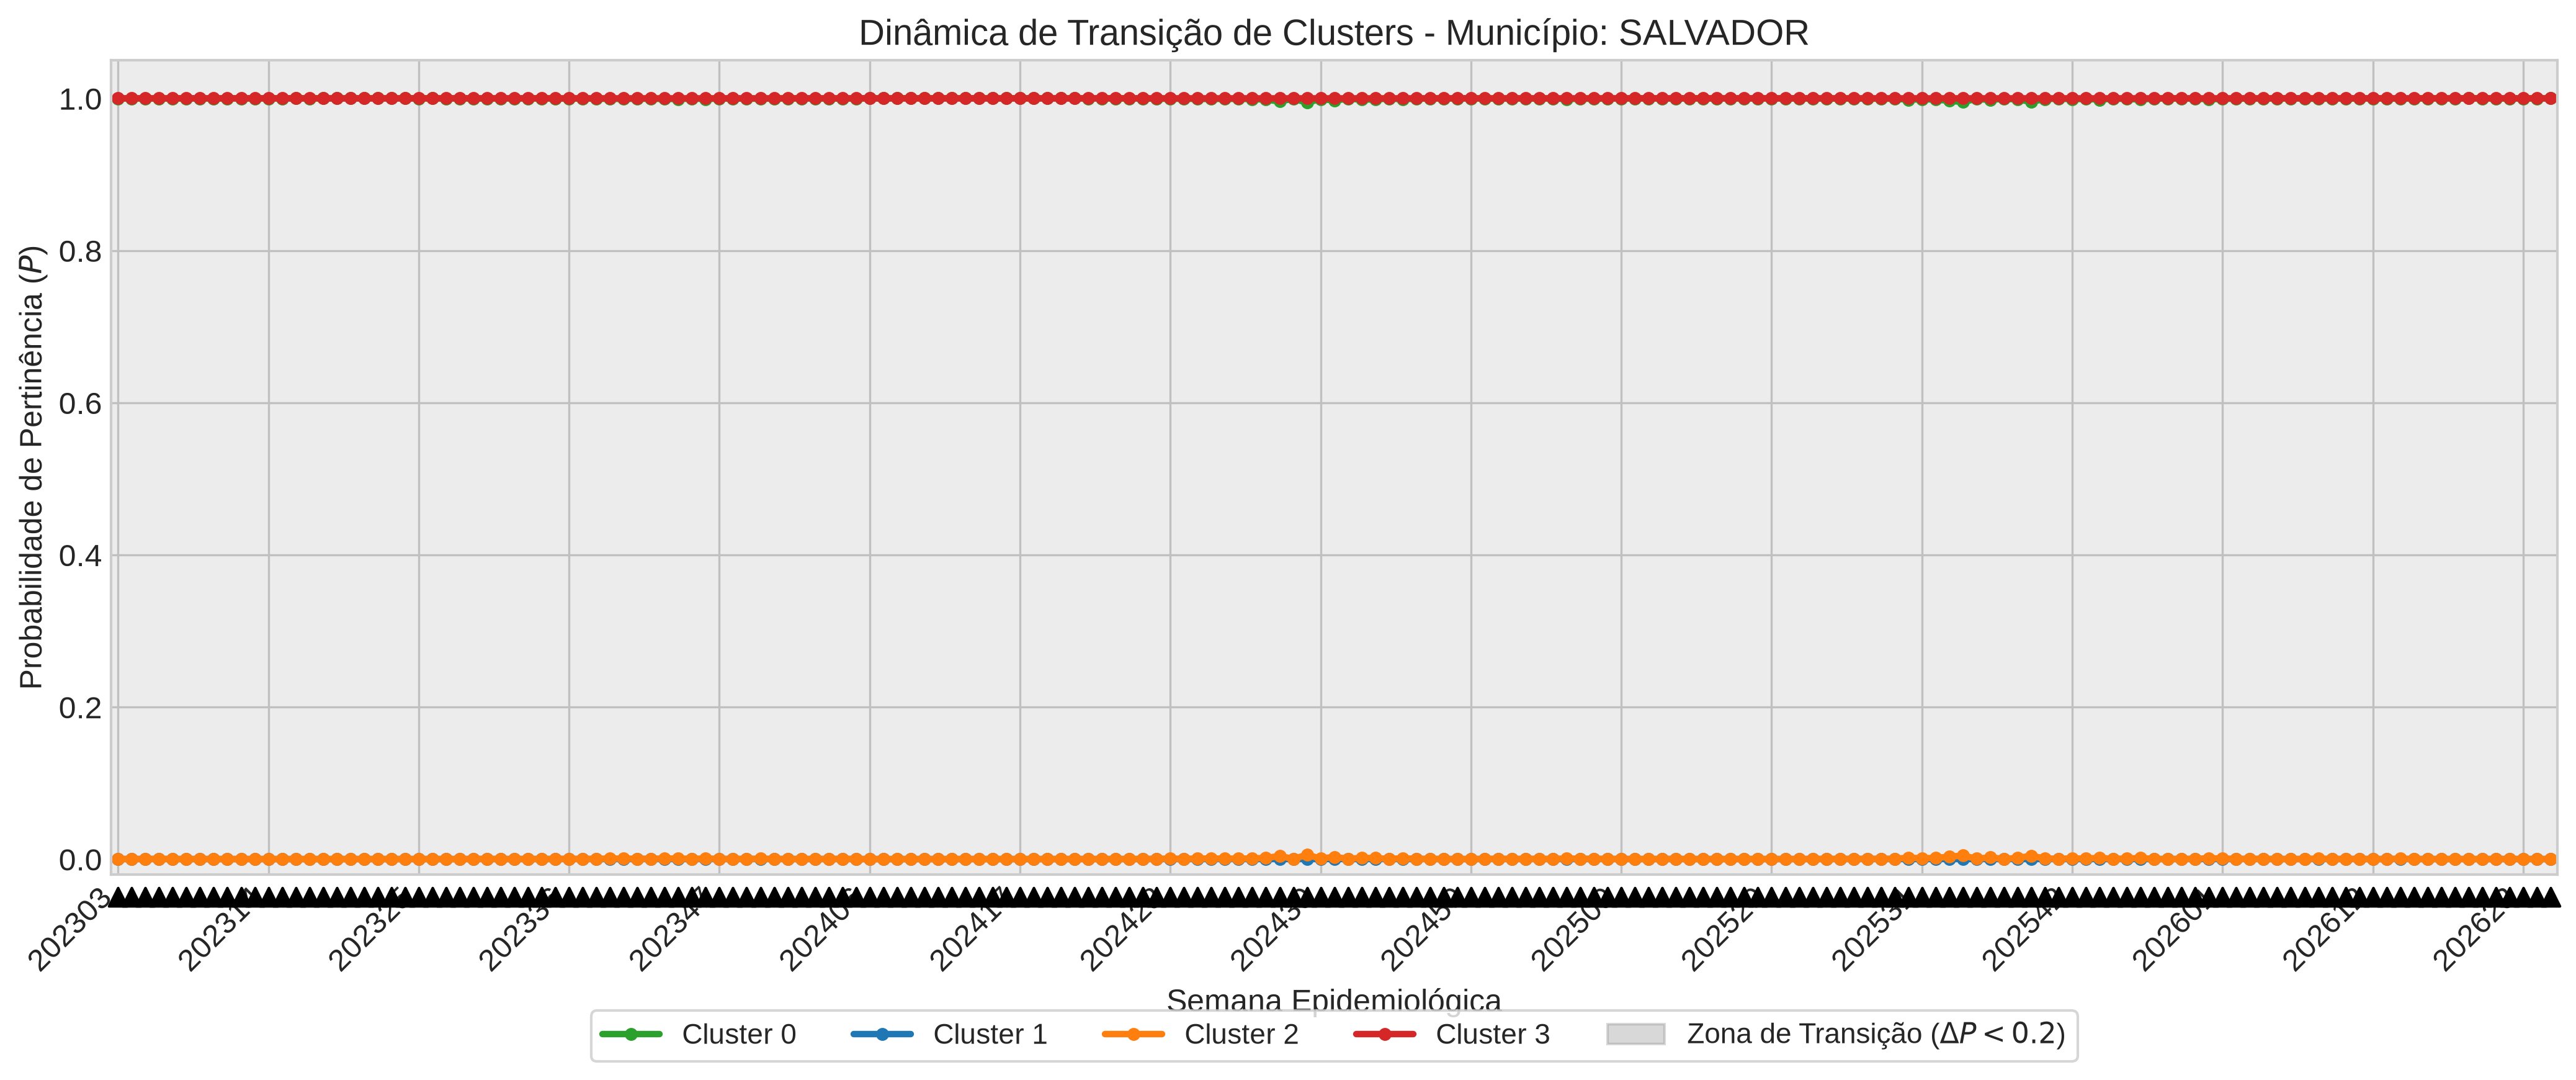

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Configurações de estilo para artigo acadêmico
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 11,
    'figure.dpi': 300 # Alta resolução para paper
})

# Paleta de cores para os clusters (ajuste conforme o significado de cada cluster)
cores_clusters = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'] # Verde, Azul, Laranja, Vermelho

def plot_dinamica_transicao(df, municipio_nome, K=4, limiar_incerteza=0.20):
    # Filtrar e ordenar dados do município
    df_mun = df[df['mun_chave'] == municipio_nome].copy()
    df_mun = df_mun.sort_values('SEM_NOT')
    
    # Criar eixo X categórico (semanas) e numérico para o plot contínuo
    semanas = df_mun['SEM_NOT'].astype(str).tolist()
    x = np.arange(len(semanas))
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    prob_cols = [f'prob_C{i}' for i in range(K)]
    probs_matrix = df_mun[prob_cols].values
    
    # 1. Plotar as linhas de probabilidade de cada cluster
    for i in range(K):
        ax.plot(x, probs_matrix[:, i], label=f'Cluster {i}', color=cores_clusters[i], linewidth=2.5, marker='o', markersize=4)

    # 2. Identificar e sombrear zonas de "Incerteza / Transição"
    # Onde a diferença entre a maior probabilidade e a segunda maior é menor que limiar_incerteza
    for idx in range(len(x)):
        p_sorted = np.sort(probs_matrix[idx, :])[::-1] # Ordena do maior pro menor
        diff = p_sorted[0] - p_sorted[1]
        
        if diff < limiar_incerteza:
            # Pinta uma faixa vertical suave
            ax.axvspan(idx - 0.5, idx + 0.5, color='gray', alpha=0.15, lw=0)
            
            # Adiciona um marcador de alerta na base do gráfico
            ax.scatter(idx, -0.05, color='black', marker='^', s=50, clip_on=False)

    # 3. Estilização do Gráfico
    ax.set_ylim(-0.02, 1.05)
    ax.set_xlim(-0.5, len(x) - 0.5)
    
    # Configurar eixo X para mostrar algumas semanas (evitar sobreposição)
    step = max(1, len(x) // 15)
    ax.set_xticks(x[::step])
    ax.set_xticklabels([semanas[i] for i in range(0, len(x), step)], rotation=45, ha='right')
    
    ax.set_ylabel('Probabilidade de Pertinência ($P$)')
    ax.set_xlabel('Semana Epidemiológica')
    ax.set_title(f'Dinâmica de Transição de Clusters - Município: {municipio_nome}')
    
    # Legenda customizada incluindo o marcador de transição
    handles, labels = ax.get_legend_handles_labels()
    patch_transicao = mpatches.Patch(color='gray', alpha=0.3, label=r'Zona de Transição ($\Delta P < 0.2$)')
    handles.append(patch_transicao)
    
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=K+1, frameon=True)
    
    plt.tight_layout()
    plt.show()

# Escolha um município que apresentou mudança de clusters nas análises anteriores
# Exemplo: municipio_alvo = "SALVADOR"
municipios_disponiveis = "SALVADOR"
if len(municipios_disponiveis) > 0:
    plot_dinamica_transicao(df_model_final, municipios_disponiveis, K=K_opt)